### Example:
- Which models use for training
- Comparison of selected models
- How is model performance

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [35]:
df = pd.read_csv("ai_job_replacement_2020_2026_v2.csv")

In [36]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

# Find categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns

# Encode them
for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col])

In [53]:
X = df.drop([
    "automation_risk_category",
    "automation_risk_percent",
    "ai_replacement_score",
    "ai_disruption_intensity",
    "reskilling_urgency_score"
], axis=1)

y = df["automation_risk_category"]

In [55]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [56]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_acc = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_acc)

Logistic Regression Accuracy: 0.944


In [57]:
dt = DecisionTreeClassifier()

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

dt_acc = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_acc)

Decision Tree Accuracy: 0.9733333333333334


In [58]:
rf = RandomForestClassifier(n_estimators=100)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 0.9313333333333333


In [59]:
print("Classification Report (Random Forest):")

print(classification_report(y_test, rf_pred))

Classification Report (Random Forest):
              precision    recall  f1-score   support

           0       0.96      0.94      0.95       902
           1       0.96      0.89      0.92       803
           2       0.90      0.95      0.92      1295

    accuracy                           0.93      3000
   macro avg       0.94      0.93      0.93      3000
weighted avg       0.93      0.93      0.93      3000



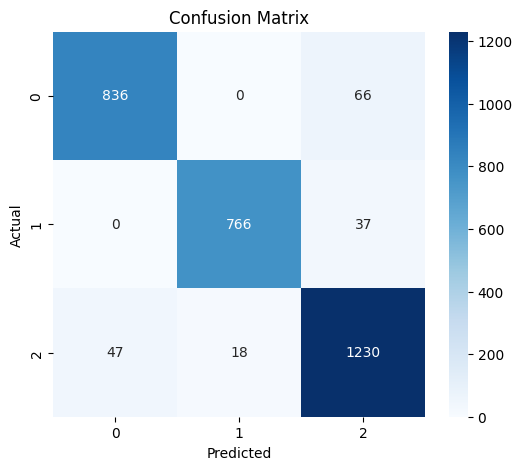

In [77]:
cm = confusion_matrix(y_test, rf_pred) 
cm = confusion_matrix(y_test, dt_pred)
cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [78]:
models = ["Logistic Regression", "Decision Tree", "Random Forest"]
scores = [lr_acc, dt_acc, rf_acc]

comparison = pd.DataFrame({
    "Model": models,
    "Accuracy": scores
})

print(comparison)

                 Model  Accuracy
0  Logistic Regression  0.944000
1        Decision Tree  0.973333
2        Random Forest  0.931333


In [69]:
importance = rf.feature_importances_

feature_names = X.columns

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

print(feature_importance.head(10))

                        Feature  Importance
13    skill_transition_pressure    0.342072
5               skill_gap_index    0.239888
0                        job_id    0.040269
11            ai_adoption_level    0.040201
10     remote_feasibility_score    0.039599
9   skill_demand_growth_percent    0.039567
7              salary_after_usd    0.037827
8         salary_change_percent    0.037510
6             salary_before_usd    0.037451
14        wage_volatility_index    0.037345


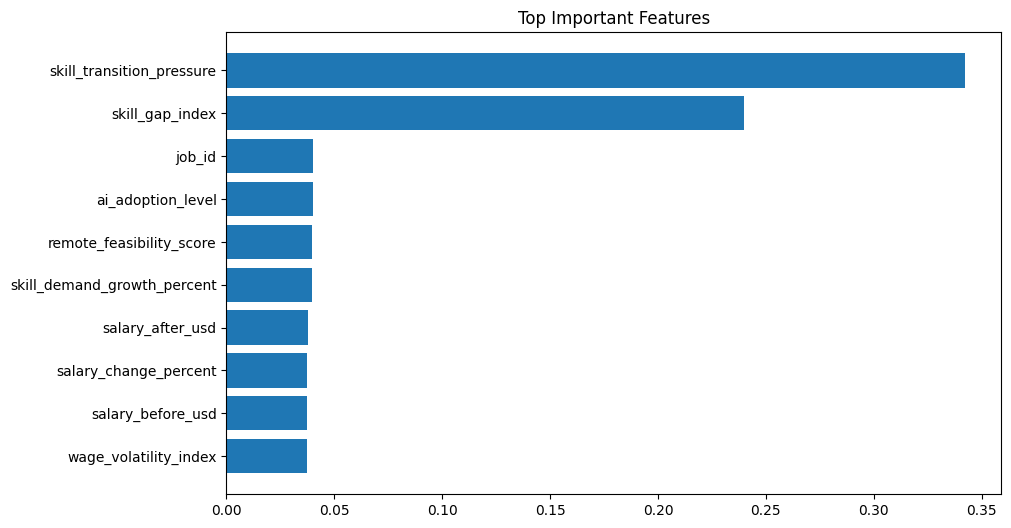

In [68]:
plt.figure(figsize=(10,6))
plt.barh(feature_importance["Feature"][:10], feature_importance["Importance"][:10])
plt.title("Top Important Features")
plt.gca().invert_yaxis()
plt.show()